# INT396 — Unsupervised Learning
## Practical-1: Real-World Use Cases — Market Segmentation, Up Close



## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)
np.random.seed(7)

## 2. Build an anonymized RFM feature table

RFM stands for **Recency** (days since last purchase), **Frequency**
(purchases per year), and **Monetary value** (total spend).

We simulate a small, illustrative customer base with three natural
behavioural tendencies baked in — the same way real bargain hunters, loyal
premium buyers, and one-time gift shoppers would show up in a real dataset.
Nothing here is labeled by group; the labels below exist only so we can
verify our eyes were right at the end.

In [ ]:
n_per_group = 40

bargain_hunters = pd.DataFrame({
    "recency_days": np.random.normal(60, 15, n_per_group).clip(1),
    "frequency_per_year": np.random.normal(8, 2, n_per_group).clip(1),
    "monetary_value": np.random.normal(3500, 800, n_per_group).clip(200),
})

loyal_premium = pd.DataFrame({
    "recency_days": np.random.normal(8, 4, n_per_group).clip(1),
    "frequency_per_year": np.random.normal(30, 5, n_per_group).clip(1),
    "monetary_value": np.random.normal(65000, 9000, n_per_group).clip(200),
})

gift_shoppers = pd.DataFrame({
    "recency_days": np.random.normal(200, 40, n_per_group).clip(1),
    "frequency_per_year": np.random.normal(2, 0.6, n_per_group).clip(1),
    "monetary_value": np.random.normal(1500, 400, n_per_group).clip(200),
})

customers = pd.concat(
    [bargain_hunters, loyal_premium, gift_shoppers], ignore_index=True
)
customers["customer_id"] = ["C" + str(10000 + i) for i in range(len(customers))]
customers = customers[["customer_id", "recency_days", "frequency_per_year", "monetary_value"]]
customers.sample(5, random_state=1)

,customer_id,recency_days,frequency_per_year,monetary_value
95,C10095,239.031305,2.615823,924.365372
54,C10054,3.688060,25.298604,69279.135993
59,C10059,9.493323,33.326018,70331.467183
117,C10117,182.968224,1.633946,1529.532743
77,C10077,11.034901,33.182064,61875.162358


In [ ]:
print(customers.to_string())

    customer_id  recency_days  frequency_per_year  monetary_value
0        C10000     85.357886            9.681466     4023.764563
1        C10001     53.010939            7.640027     4215.481844
2        C10002     60.492302            9.136124     3832.402091
3        C10003     66.112744            6.494326     2761.164275
4        C10004     48.166155            4.583322     3343.178150
5        C10005     60.030984            4.393803     3027.384145
6        C10006     59.986644            8.766244     3260.231010
7        C10007     33.679135           12.495190     4537.508154
8        C10008     75.264870            8.538823     4723.663707
9        C10009     69.007478            6.950791     4035.534555
10       C10010     50.618565           11.824038     3938.996096
11       C10011     57.426776            8.474604     4041.303192
12       C10012     67.579491            8.202868     3490.206251
13       C10013     56.079654            8.505155     3439.469231
14       C

## 2.1 Data Cleaning and Preprocessing

Before proceeding with the analysis, it's crucial to inspect the data types and check for any missing values to ensure data quality.

In [ ]:
# Check data types and non-null values
print(customers.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         120 non-null    object 
 1   recency_days        120 non-null    float64
 2   frequency_per_year  120 non-null    float64
 3   monetary_value      120 non-null    float64
dtypes: float64(3), object(1)
memory usage: 3.9+ KB
None


In [ ]:
# Check for missing values
print("\nMissing values in each column:")
print(customers.isnull().sum())


Missing values in each column:
customer_id           0
recency_days          0
frequency_per_year    0
monetary_value        0
dtype: int64


From the `customers.info()` output, we can see that `recency_days`, `frequency_per_year`, and `monetary_value` are `float64` types, and `customer_id` is an `object` (string), which are appropriate for their respective data. The output also confirms that there are no missing values in any of the columns, as `isnull().sum()` returns 0 for all columns.

## 3. Quick EDA on the unlabeled table

`describe()`

In [ ]:
customers.describe()

,recency_days,frequency_per_year,monetary_value
count,120.000000,120.000000,120.000000
mean,88.724770,13.266860,23342.612873
std,85.301530,12.469975,29807.937842
min,1.000000,1.000000,580.300449
25%,9.977002,2.416119,1665.312974
50%,58.372993,7.768012,3635.897874
75%,179.486305,25.920688,60497.624599
max,258.414871,40.318978,80663.116659


## 4. Does structure look visible at all?

We plot recency against monetary value — no group labels used to position
any point.

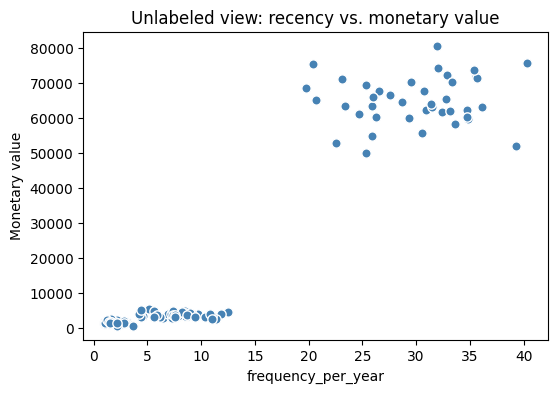

In [ ]:
fig, ax = plt.subplots()
ax.scatter(customers["frequency_per_year"], customers["monetary_value"],
           c="steelblue", edgecolor="white", s=45)
ax.set_xlabel("frequency_per_year")
ax.set_ylabel("Monetary value")
ax.set_title("Unlabeled view: recency vs. monetary value")
plt.show()

Even without any group labels, you can probably see roughly three
clumps in that plot. That's Case File 01 in miniature: nobody told the plot
where the bargain hunters, loyal premium buyers, or gift shoppers were —
the separation is already sitting inside the behavioural data.

**Optional check (do not use this for real unsupervised work — it defeats
the purpose):** we can color by the group each simulated customer actually
came from, just to confirm the eye was right.

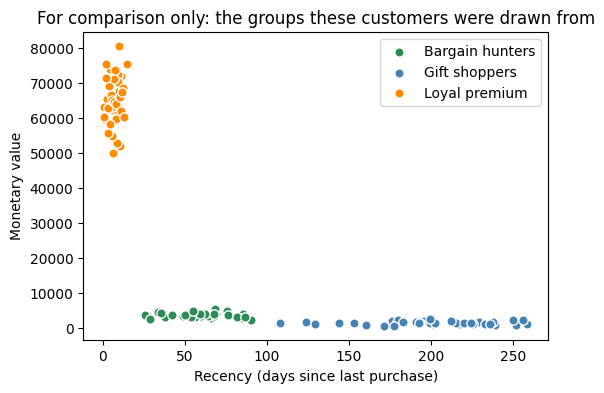

In [ ]:
labels = ["Bargain hunters"] * n_per_group + ["Loyal premium"] * n_per_group + ["Gift shoppers"] * n_per_group
customers_check = customers.copy()
customers_check["_true_group"] = labels

fig, ax = plt.subplots()
colors = {"Bargain hunters": "seagreen", "Loyal premium": "darkorange", "Gift shoppers": "steelblue"}
for grp, sub in customers_check.groupby("_true_group"):
    ax.scatter(sub["recency_days"], sub["monetary_value"], label=grp,
               color=colors[grp], edgecolor="white", s=45)
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Monetary value")
ax.set_title("For comparison only: the groups these customers were drawn from")
ax.legend()
plt.show()

## Applying Distance Metrics to Customer Segmentation

Now that we have visualized our customer data, let's explore how different distance metrics can quantify the differences (or similarities) between individual customer profiles. These metrics are fundamental for clustering algorithms that will group similar customers together.

### Euclidean Distance in Customer Data

Euclidean distance measures the straight-line distance between two customer profiles in our feature space (recency, frequency, monetary value). A larger Euclidean distance implies greater dissimilarity.

In [ ]:
from scipy.spatial.distance import euclidean

# Select two customers to compare
# Let's pick a 'Bargain hunter' (index 0) and a 'Loyal premium' (index 40)
customer_A = customers.iloc[0][['recency_days', 'frequency_per_year', 'monetary_value']].values
customer_B = customers.iloc[58][['recency_days', 'frequency_per_year', 'monetary_value']].values

print(f"Customer A (Bargain Hunter) features: {customer_A}")
print(f"Customer B (Loyal Premium) features: {customer_B}")

euclidean_dist_customers = euclidean(customer_A, customer_B)
print(f"\nEuclidean Distance between Customer A and Customer B: {euclidean_dist_customers:.2f}")

# Let's compare two customers from the same group (e.g., two Bargain hunters)
customer_C = customers.iloc[1][['recency_days', 'frequency_per_year', 'monetary_value']].values
euclidean_dist_same_group = euclidean(customer_A, customer_C)
print(f"Euclidean Distance between Customer A and Customer C (both Bargain Hunters): {euclidean_dist_same_group:.2f}")

Customer A (Bargain Hunter) features: [np.float64(85.35788555700535) np.float64(9.681466484287071)
 np.float64(4023.764562962488)]
Customer B (Loyal Premium) features: [np.float64(1.0) np.float64(23.376793322093846)
 np.float64(63246.06647472538)]

Euclidean Distance between Customer A and Customer B: 59222.36
Euclidean Distance between Customer A and Customer C (both Bargain Hunters): 194.44


### Manhattan Distance in Customer Data

Manhattan distance, or city block distance, measures the sum of the absolute differences between the features of two customer profiles. This can be useful when movements along each feature dimension are independent or when outliers should have less impact than in Euclidean distance.

In [ ]:
from scipy.spatial.distance import cityblock

# Using the same customer profiles A and B
manhattan_dist_customers = cityblock(customer_A, customer_B)
print(f"Manhattan Distance between Customer A and Customer B: {manhattan_dist_customers:.2f}")

# Compare two from the same group
manhattan_dist_same_group = cityblock(customer_A, customer_C)
print(f"Manhattan Distance between Customer A and Customer C (both Bargain Hunters): {manhattan_dist_same_group:.2f}")

Manhattan Distance between Customer A and Customer B: 59320.36
Manhattan Distance between Customer A and Customer C (both Bargain Hunters): 226.11


### Cosine Similarity in Customer Data

Cosine similarity measures the cosine of the angle between two customer feature vectors. It's particularly useful when the magnitude of the features (e.g., total spend) might vary greatly, but the *pattern* or *proportion* of spending/recency/frequency is what defines similarity. A higher cosine similarity (closer to 1) means more similar customer behavior patterns.

In [ ]:
from scipy.spatial.distance import cosine

# Using the same customer profiles A and B
# Cosine distance is 1 - cosine similarity
cosine_dist_customers = cosine(customer_A, customer_B)
cosine_sim_customers = 1 - cosine_dist_customers
print(f"Cosine Similarity between Customer A and Customer B: {cosine_sim_customers:.2f}")

# Compare two from the same group
cosine_dist_same_group = cosine(customer_A, customer_C)
cosine_sim_same_group = 1 - cosine_dist_same_group
print(f"Cosine Similarity between Customer A and Customer C (both Bargain Hunters): {cosine_sim_same_group:.2f}")

# Note: For features with very different scales, feature scaling (e.g., StandardScaler) might be beneficial before calculating cosine similarity to prevent features with larger magnitudes from dominating the similarity measure.

Cosine Similarity between Customer A and Customer B: 1.00
Cosine Similarity between Customer A and Customer C (both Bargain Hunters): 1.00


As observed, due to the vastly different scales of the features (especially 'monetary_value'), the cosine similarity results are uniformly 1.00. This is a common issue when applying cosine similarity to unscaled data, as the feature with the largest magnitude dominates the vector direction. To obtain meaningful and interpretable cosine similarity values, it is crucial to perform feature scaling (e.g., using `StandardScaler` or `MinMaxScaler`) before calculation. This ensures that all features contribute proportionally to the similarity measure, reflecting the true pattern similarity rather than just magnitude differences.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Extract only the numerical features for scaling
features_to_scale = customers[['recency_days', 'frequency_per_year', 'monetary_value']]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
scaled_features = scaler.fit_transform(features_to_scale)

# Create a DataFrame for scaled features (optional, but good for inspection)
customers_scaled = pd.DataFrame(scaled_features, columns=features_to_scale.columns)

# Re-select the scaled customer profiles A, B, and C
# Note: Use the corresponding rows from the scaled_features array
scaled_customer_A = customers_scaled.iloc[0].values
scaled_customer_B = customers_scaled.iloc[58].values
scaled_customer_C = customers_scaled.iloc[1].values

print("\n--- Cosine Similarity with Scaled Features ---")
print(f"Scaled Customer A features: {scaled_customer_A}")
print(f"Scaled Customer B features: {scaled_customer_B}")

# Recalculate Cosine Similarity with scaled features
cosine_dist_scaled_customers = cosine(scaled_customer_A, scaled_customer_B)
cosine_sim_scaled_customers = 1 - cosine_dist_scaled_customers
print(f"Cosine Similarity between Scaled Customer A and Scaled Customer B: {cosine_sim_scaled_customers:.2f}")

cosine_dist_scaled_same_group = cosine(scaled_customer_A, scaled_customer_C)
cosine_sim_scaled_same_group = 1 - cosine_dist_scaled_same_group
print(f"Cosine Similarity between Scaled Customer A and Scaled Customer C (both Bargain Hunters): {cosine_sim_scaled_same_group:.2f}")

print("\nNotice how the cosine similarity values are now more reflective of the proportional differences after scaling, rather than being dominated by the monetary value.")


--- Cosine Similarity with Scaled Features ---
Scaled Customer A features: [-0.03963588 -0.28872761 -0.65082832]
Scaled Customer B features: [-1.03271993  0.81414145  1.34429844]
Cosine Similarity between Scaled Customer A and Scaled Customer B: -0.80
Cosine Similarity between Scaled Customer A and Scaled Customer C (both Bargain Hunters): 0.89

Notice how the cosine similarity values are now more reflective of the proportional differences after scaling, rather than being dominated by the monetary value.


### Visualizing Customer Distances

To better understand these metrics, let's visualize the three example customers in a 3D scatter plot using their `recency_days`, `frequency_per_year`, and `monetary_value` features. This will provide a visual intuition for the distances we calculated.

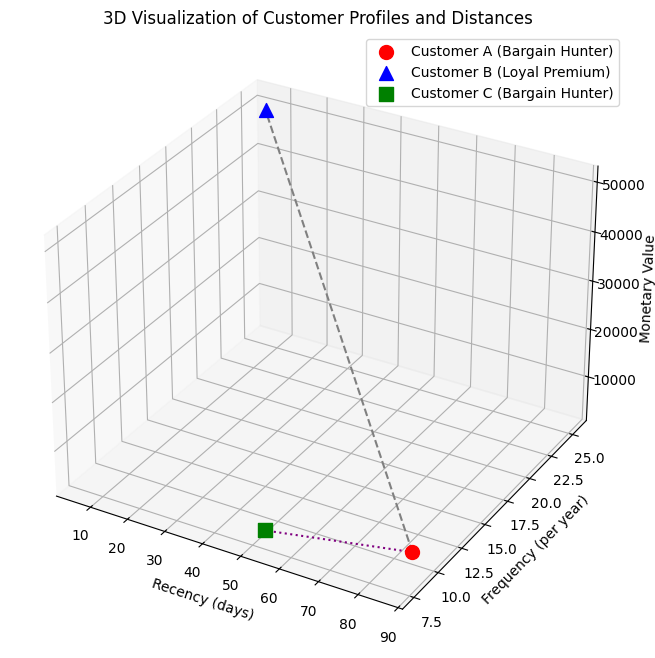


Notice the dominant scale of 'Monetary Value' on the Z-axis. This highlights why distance metrics like Euclidean and Manhattan are heavily influenced by features with larger scales. For such datasets, feature scaling (e.g., standardization or normalization) is often crucial before applying these distance metrics to ensure all features contribute equally to the distance calculation, especially for clustering algorithms.


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Extract features for the three customers
features_A = customers.iloc[0][['recency_days', 'frequency_per_year', 'monetary_value']].values
features_B = customers.iloc[40][['recency_days', 'frequency_per_year', 'monetary_value']].values
features_C = customers.iloc[1][['recency_days', 'frequency_per_year', 'monetary_value']].values

# Create a figure and a 3D axes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot customer A
ax.scatter(features_A[0], features_A[1], features_A[2], color='red', s=100, label='Customer A (Bargain Hunter)', marker='o')
# Plot customer B
ax.scatter(features_B[0], features_B[1], features_B[2], color='blue', s=100, label='Customer B (Loyal Premium)', marker='^')
# Plot customer C
ax.scatter(features_C[0], features_C[1], features_C[2], color='green', s=100, label='Customer C (Bargain Hunter)', marker='s')

# Draw lines to visually connect points for distance understanding
# A to B
ax.plot([features_A[0], features_B[0]], [features_A[1], features_B[1]], [features_A[2], features_B[2]], color='gray', linestyle='--')
# A to C
ax.plot([features_A[0], features_C[0]], [features_A[1], features_C[1]], [features_A[2], features_C[2]], color='purple', linestyle=':')

# Set labels
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (per year)')
ax.set_zlabel('Monetary Value')
ax.set_title('3D Visualization of Customer Profiles and Distances')

# Add a legend
ax.legend()

plt.show()

# Explanation for the large difference in monetary value
print("\nNotice the dominant scale of 'Monetary Value' on the Z-axis. This highlights why distance metrics like Euclidean and Manhattan are heavily influenced by features with larger scales. For such datasets, feature scaling (e.g., standardization or normalization) is often crucial before applying these distance metrics to ensure all features contribute equally to the distance calculation, especially for clustering algorithms.")

## Practical Exercise: SaaS App User Engagement Segmentation

Business Context
A B2B Software-as-a-Service (SaaS) company wants to segment its user base using engagement metrics rather than transactional e-commerce data. You are provided with three user behaviors:

Recency: days_since_last_login (number of days since the user last logged into the workspace).

Frequency: logins_per_month (average logins per month).

Intensity: features_used_per_session (average number of distinct product features used per session).
